In [1]:
import sys

dir_git = "/Users/usuario/git/sisepuede"
if dir_git not in sys.path:
    sys.path.append(dir_git)
    
import importlib
import matplotlib.pyplot as plt
import numpy as np
import os, os.path
import pandas as pd
import pathlib
import sisepuede.core.support_classes as sc
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.utilities._toolbox as sf
import utils.common_data_needs as cdn
import warnings
warnings.filterwarnings("ignore")

plt.style.use("dark_background", )



/Users/usuario/git/sisepuede/sisepuede/utilities/_toolbox.py:551: UserWarning: Path '/Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2026-04-28T16;15;00.902327' not found. It will not be created.
  warnings.warn(msg)
/Users/usuario/git/sisepuede/sisepuede/core/model_attributes.py:6830: UserWarning: 

                        MISSIONSEARCHNOTE: As of 2023-10-06, there is a temporary solution 
                        implemeted in ModelAttributes.get_variable_to_simplex_group_dictionary() 
                        to ensure that transition probability rows are enforced on a simplex.
                        
                        
                        FIX THIS ASAP TO DERIVE PROPERLY.
                        
                        
  warnings.warn(
/Users/usuario/git/sisepuede/sisepuede/utilities/_toolbox.py:551: UserWarning: Path '/Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2026-04-28T16;15;01.251755' not found. It will not be created.
  warnings.warn(msg)
/Use

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1580.4 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
/Users/usuario/git/sisepuede/sisepuede/utilities/_toolbox.py:2677: UserWarning: Warning passed from optional_log: Successfully initialized JuMP optimizer from solver module HiGHS..
  warnings.warn(f"Warning passed from optional_log: {msg}.")


# Initialize some SISEPUEDE components

In [2]:
dict_ssp = cdn._setup_sisepuede_elements()

matt = dict_ssp.get("model_attributes", )
models = dict_ssp.get("models", )
regions = dict_ssp.get("regions", )
time_periods = dict_ssp.get("time_periods", )

# setup region
_REGION_NAME = "uganda"
_REGION_ISO = regions.return_region_or_iso(_REGION_NAME, return_type = "iso")

# base dataset
df_uganda = cdn.get_raw_ssp_inputs()


##  SOME GLOBALS

# categories
_CAT_ENFU_CRUDE = "fuel_crude"
_CAT_ENFU_DIE = "fuel_diesel"
_CAT_ENFU_GAS = "fuel_gasoline"
_CAT_ENFU_HFO = "fuel_oil"
_CAT_ENFU_HGL = "fuel_hydrocarbon_gas_liquids"
_CAT_ENFU_KER = "fuel_kerosene"
_CAT_ENTC_REFINE = "fp_petroleum_refinement"

# fields
_FIELD_DEMAND_CRUDE_KBD = "demand_fuel_crude_kbd"           # thousand barrels per day
_FIELD_DEMAND_CRUDE_PJA = "demand_fuel_crude_pja"           # pj/year
_FIELD_PRODUCTION_CRUDE_KBD = "production_fuel_crude_kbd"   # thousand barrels per day
_FIELD_PRODUCTION_CRUDE_PJA = "production_fuel_crude_pja"   # pj/year

# year to estimate out to
_YEAR_TARGET = 2100



In [199]:
# build a dataframe with the universe of years
df_space_years = pd.DataFrame(
    {
        time_periods.field_year: range(2015, _YEAR_TARGET + 1),
    }
)


# Load data we'll work with

- The [2023 Uganda/IEA Energy Transition Plan](https://www.iea.org/reports/uganda-energy-transition-plan) describes average annual production of Crude oilby decade in the Albertine Graben with estimates for total crude production  


##  1. Crude Oil Exports and Import Fractions

- Figure 2.26 shows estimates of production and oil demands
- We combine these two to estimate the fraction of oil imported and total exports
- Note that [IEA](https://www.iea.org/countries/uganda/oil) doesn't show any crude oil production in Uganda in 2025, so we estimate start date as 2026 (and 2026 will be 0 for interpolation)

  
![Crude Oil Production](./input_data/iea_etp/crude_oil_production_projection.png)


###  Additionally, we can estimate historical consumption using Figure 1.1

![Total Energy Supply and Production](./input_data/iea_etp/total_energy_supply_and_consumption.png)

In [4]:
est_2016 = 45*3.6/4.7
est_2016

34.46808510638298

### First, build estimates of values shown in figure 2.26
- Beyond 2050, use projection

In [200]:

# est 2010, 2016 as indices 1.9,3.6 versus index of 4.7 in 2021
ind_scale_2010 = 1.9/4.7
ind_scale_2016 = 3.6/4.7

# these are taken from visual estimates of dots in Figure 2.26 
# and supplemented with the index (right) for oil in Figure 1.1
df_demand_crude = pd.DataFrame(
    {
        time_periods.field_year: [2010, 2016, 2021, 2030, 2040, 2050,],
        _FIELD_DEMAND_CRUDE_KBD: [45*ind_scale_2010, 45*ind_scale_2016, 45, 105, 145, 125, ]
    }
)

# these are taken from visual estimates at the "mean" of the 
# red boxes in Figure 2.26
df_production_crude = pd.DataFrame(
    {
        time_periods.field_year: [2026, 2030, 2040, 2050],
        _FIELD_PRODUCTION_CRUDE_KBD: [0, 220, 126, 65] 
    }
)

In [201]:
##  PROJECT CRUDE (just to have something beyond 2050)

def do_project(
    df: pd.DataFrame,
    field_data: str,
    delta_y: int = 10,
    field_year: str = time_periods.field_year,
    max_lookback_project: int = 3,
) -> pd.DataFrame:
    """Use iterative regression with bounded history to project forward.

    NOTE: picks the greater between the regression and half the last value.
        
    """
    
    arr = df[[field_data]].to_numpy().copy()
    year_0 = df[field_year].max()
    
    n_proj = int((_YEAR_TARGET - year_0)/delta_y)
    
    # lists that will be updated
    years = []
    vec_new = []
    
    # iteratively apply a constrained lookback regression
    for i in range(n_proj):
        val_new = sf.project_from_array(
            arr,
            max_deviation_from_mean = 1.0,
            max_lookback = max_lookback_project,
        )
    
        val_new[0] = max(val_new[0], arr[-1, 0]/2)
        arr = np.concatenate([arr, np.array([val_new])])
    
        
        vec_new.append(val_new[0])
        years.append(year_0 + (i + 1)*delta_y)
    
    # projection df
    df_proj = pd.DataFrame(
        {
            field_year: years,
            field_data: vec_new,
        }
    )

    return df_proj


    
##  PROJECT PRODUCTION AND DEMAND

df_production_crude_proj = do_project(
    df_production_crude,
    _FIELD_PRODUCTION_CRUDE_KBD,
)

df_demand_crude_proj = do_project(
    df_demand_crude,
    _FIELD_DEMAND_CRUDE_KBD,
    max_lookback_project = 2
)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='year', ylabel='Production of crude in kbl/day'>)

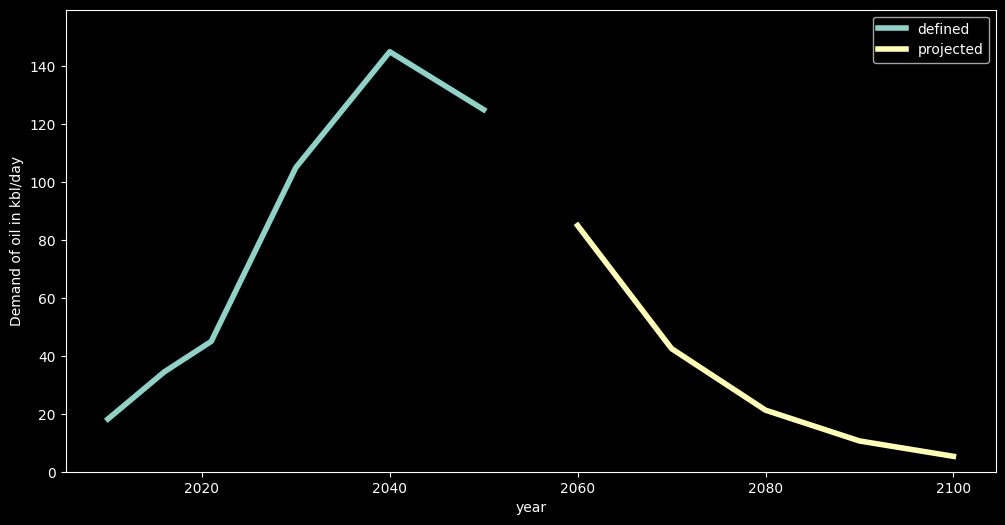

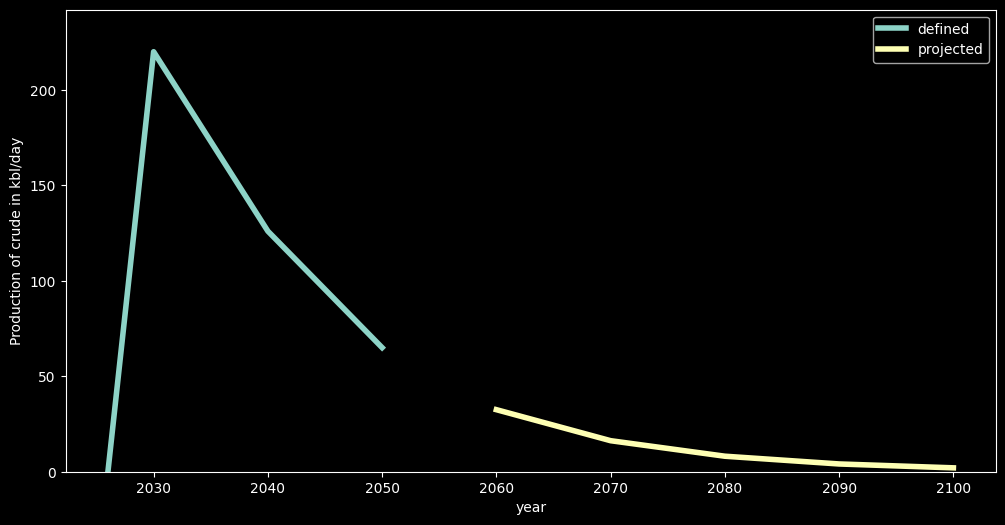

In [202]:

def plot_projections(
    df_defined: pd.DataFrame,
    df_projected: pd.DataFrame,
    field: str,
    ylabel: str,
    field_year: str = time_periods.field_year,
) -> 'plt.plot':
    """Plot comparison of defined (hist) with projected
    """
    fig, ax = plt.subplots(figsize = (12, 6))
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(df_defined[field].max(), df_projected[field].max())*1.1)
    
    (
        df_defined
        .rename(
            columns = {field: "defined", },
        )
        .plot(
            x = field_year, 
            ax = ax, 
            linewidth = 4, 
        )
    )
    
    (
        df_projected
        .rename(
            columns = {field: "projected", },
        )
        .plot(
            x = field_year, 
            ax = ax, 
            linewidth = 4, 
        )
    )

    out = (fig, ax, )
    
    return out

    
plot_projections(
    df_demand_crude,
    df_demand_crude_proj,
    _FIELD_DEMAND_CRUDE_KBD,
    "Demand of oil in kbl/day",
)


    
plot_projections(
    df_production_crude,
    df_production_crude_proj,
    _FIELD_PRODUCTION_CRUDE_KBD,
    "Production of crude in kbl/day",
)

##  Next, smooth out the estimates


<Axes: xlabel='year', ylabel='Production of oil in kbl/day'>

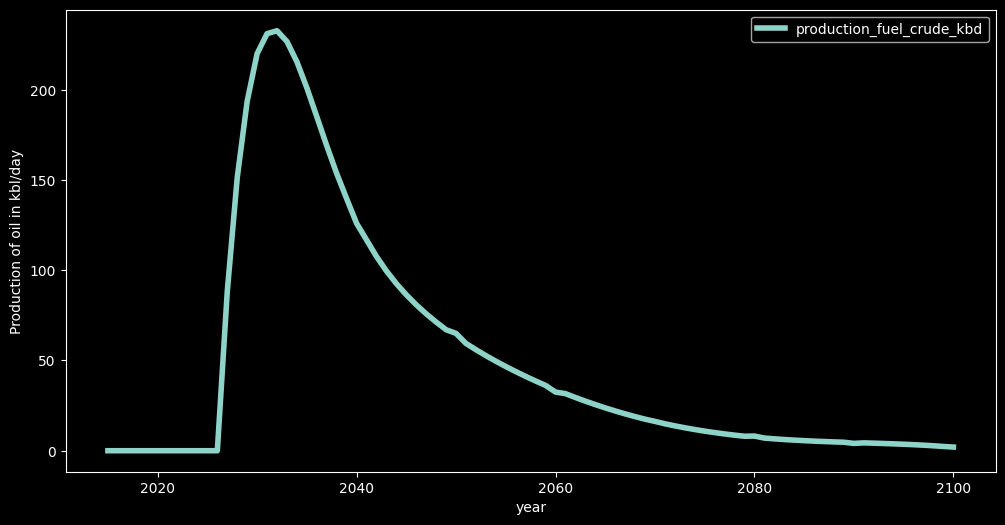

In [203]:
##  Start with production
df_production_crude_full = (
    pd.merge(
        df_space_years,
        pd.concat([df_production_crude, df_production_crude_proj], axis = 0, ),
        how = "left",
    )
    .interpolate("spline", order = 4, )
    .bfill()
)

fig, ax = plt.subplots(figsize = (12, 6))
ax.set_ylabel("Production of oil in kbl/day")
df_production_crude_full.plot(
    ax = ax,
    linewidth = 4,
    x = time_periods.field_year, 
)

##  Note, Box 2.3 says 1.7 billion barrels are accessible

- **Box 2.**: _The Albertine Graben is a 500 km long the rift valley in the Western Region of
Uganda and neighbouring Democratic Republic of Congo. Oil deposits in the
region around Lake Albert were first discovered in 2006, with total oil in place
reserves estimated at 6.5 billion barrels, of which 1.7 billion barrels are deemed
recoverable_
- The estimate above gets close to this, with a total of 1.56 billion barrels produced from 2026 to 2100

In [204]:
total_prod = df_production_crude_full[_FIELD_PRODUCTION_CRUDE_KBD].sum()*365*1000
est = np.round(total_prod/10**9, decimals = 3)

df = df_production_crude_full[
    df_production_crude_full[_FIELD_PRODUCTION_CRUDE_KBD] > 0
]
y0 = df[time_periods.field_year].min()
y1 = df[time_periods.field_year].max()
print(f"Estimate of total production from {y0} - {y1}: {est} billion barrels")

Estimate of total production from 2027 - 2100: 1.563 billion barrels


###  Next, smooth out demand estimate

<Axes: xlabel='year', ylabel='Demand for oil in kbl/day'>

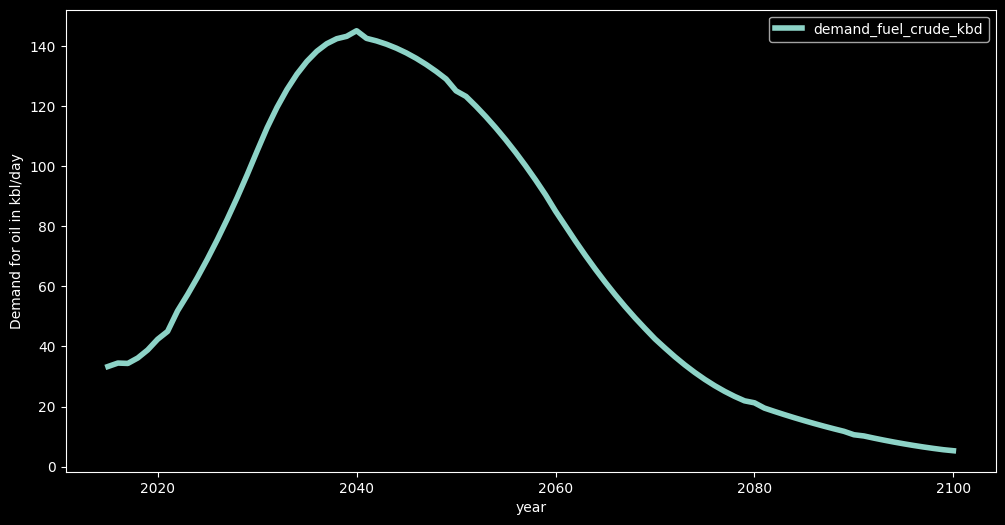

In [205]:
##  add demand
df_demand_crude_full = (
    pd.merge(
        df_space_years,
        pd.concat([df_demand_crude, df_demand_crude_proj], axis = 0, ),
        how = "left",
    )
    .interpolate("spline", order = 2, limit_direction = "both")
    #.interpolate("spline", order = 4, )
    #.bfill()
)

fig, ax = plt.subplots(figsize = (12, 6))
ax.set_ylabel("Demand for oil in kbl/day")
df_demand_crude_full.plot(
    ax = ax,
    linewidth = 4,
    x = time_periods.field_year, 
)

##  Get some conversion factors

In [206]:
modvar_exports = matt.get_variable(models.model_enercons.modvar_enfu_exports_fuel)
modvar_import_frac = matt.get_variable(models.model_enercons.modvar_enfu_frac_fuel_demand_imported)
modvar_volumetric = matt.get_variable(models.model_enercons.modvar_enfu_energy_density_volumetric)

# volumetric energy density
field_ved = modvar_volumetric.build_fields(category_restrictions = _CAT_ENFU_CRUDE, )

# unit managers
um_energy = matt.get_unit("energy")
um_volume = matt.get_unit("volume")

# units of volume for volumetric energy density
units_volume_ved = modvar_volumetric.attribute("unit_volume")
scale_factor_volume = 1000*um_volume.convert("barrel", units_volume_ved)

scale_factor_energy = um_energy.convert(
    modvar_volumetric.attribute("unit_energy"), 
    modvar_exports.attribute("unit_energy"),
)

# energy contained in 1000 barrels of oil in PJ
energy_pj_per_kb = df_uganda[field_ved].iloc[0]*scale_factor_volume*scale_factor_energy
ged_crude_pj_ktoe = cdn.get_pj_per_ktoe(df_uganda, )

###  Convert kb/d to pj/year

In [207]:
def add_pja_conversion(
    df: pd.DataFrame,
    field_in: str,
    field_out: str,
    field_year: str = time_periods.field_year, 
) -> pd.DataFrame:
    """Add field_out to df to convert kb/day (field_in) to pj/year
    """
    vec_days_per_year = np.array([
        365 + int(x%4 == 0)
        for x in list(df[field_year])
    ])

    vec_production_crude_pja = vec_days_per_year*energy_pj_per_kb*df[field_in].to_numpy()
    df[field_out] = vec_production_crude_pja

    return df


# uupdate production and demand
df_production_crude_full = add_pja_conversion(
    df_production_crude_full,
    _FIELD_PRODUCTION_CRUDE_KBD,
    _FIELD_PRODUCTION_CRUDE_PJA,
)

df_demand_crude_full = add_pja_conversion(
    df_demand_crude_full,
    _FIELD_DEMAND_CRUDE_KBD,
    _FIELD_DEMAND_CRUDE_PJA,
)



## Estimate exogenous crude exports as production - internal demand

In [209]:
df_exports_crude = pd.merge(
    df_production_crude_full
    .drop(columns = [_FIELD_PRODUCTION_CRUDE_KBD]),
    df_demand_crude_full
    .drop(columns = [_FIELD_DEMAND_CRUDE_KBD]),
    
)

# get exports column and add
field_exports_crude = modvar_exports.build_fields(category_restrictions = _CAT_ENFU_CRUDE, )
df_exports_crude[field_exports_crude] = sf.vec_bounds(
    df_exports_crude[_FIELD_PRODUCTION_CRUDE_PJA] - df_exports_crude[_FIELD_DEMAND_CRUDE_PJA],
    (0, np.inf)
)

# get import fraction estimate
df_exports_crude[field_exports_crude] = sf.vec_bounds(
    df_exports_crude[_FIELD_PRODUCTION_CRUDE_PJA] - df_exports_crude[_FIELD_DEMAND_CRUDE_PJA],
    (0, np.inf)
)


<Axes: xlabel='year'>

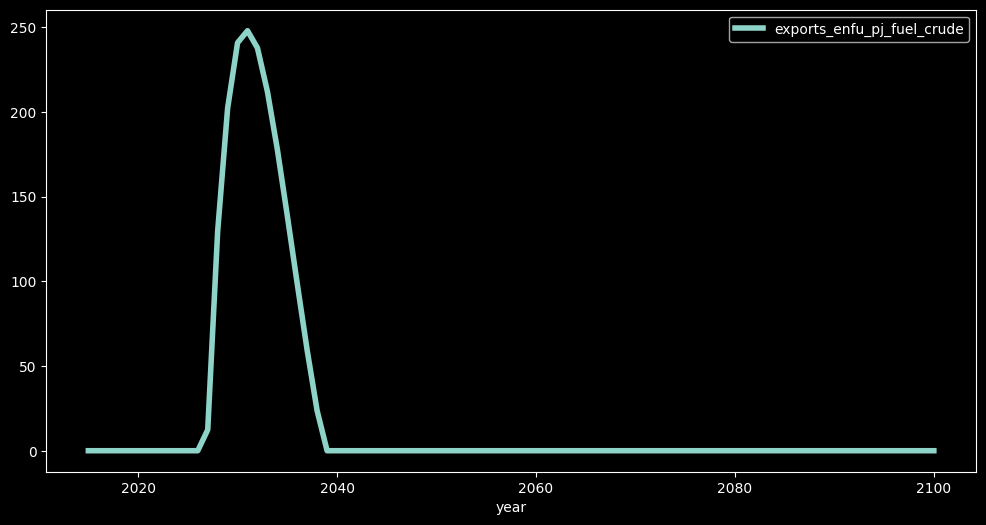

In [210]:
fig, ax = plt.subplots(figsize = (12, 6))
df_exports_crude[[time_periods.field_year, field_exports_crude]].plot(
    ax = ax,
    linewidth = 4, 
    x = time_periods.field_year,
)

### Import fraction (production - exports)/demand)

<Axes: xlabel='year'>

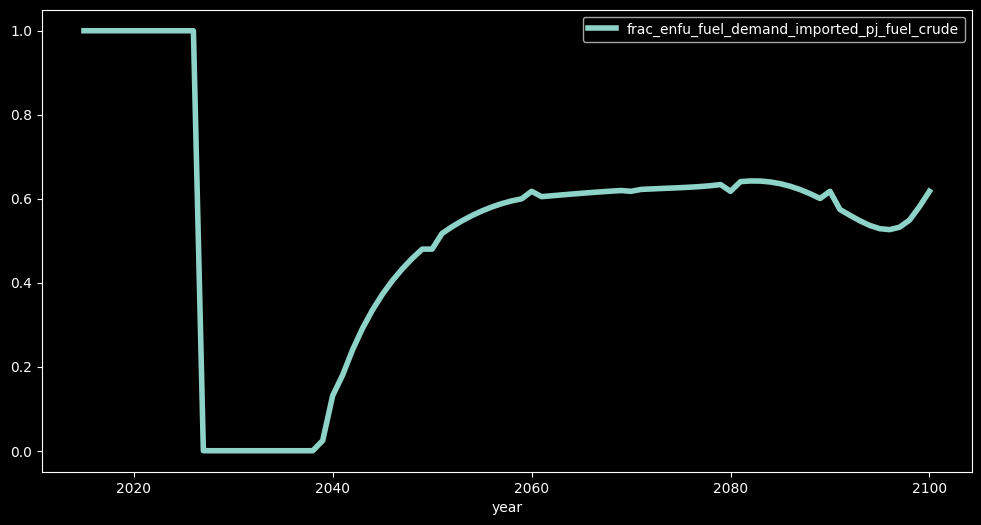

In [211]:
field_import_frac_crude = modvar_import_frac.build_fields(category_restrictions = _CAT_ENFU_CRUDE)

# get vectors
vec_exports_crude = df_exports_crude[field_exports_crude].to_numpy() 
vec_production_crude = df_exports_crude[_FIELD_PRODUCTION_CRUDE_PJA].to_numpy()  
vec_demand_crude = df_exports_crude[_FIELD_DEMAND_CRUDE_PJA].to_numpy() 

# setup import fraction
df_exports_crude[field_import_frac_crude] = sf.vec_bounds(
    1 - (vec_production_crude - vec_exports_crude)/vec_demand_crude,
    (0, 1),
)

# plot
fig, ax = plt.subplots(figsize = (12, 6))
df_exports_crude[[time_periods.field_year, field_import_frac_crude]].plot(
    ax = ax,
    linewidth = 4, 
    x = time_periods.field_year,
)

##  Assume other derivative products--gas, diesel, kerosene, hgl, and hfo--are not exported
- only plans for one refinery, so crude will be the primary export, not refined products

In [212]:
df_exports = modvar_exports.get_from_dataframe(
    df_exports_crude,
    extraction_logic = "any",
    fields_additional = [time_periods.field_year],
)

fields_add = modvar_exports.build_fields(
    category_restrictions = [
        _CAT_ENFU_DIE,
        _CAT_ENFU_HFO,
        _CAT_ENFU_GAS,
        _CAT_ENFU_KER,
    ]
)

df_exports[fields_add] = 0



##  1. Petroleum Product Import Fractions

- Figure 2.26 shows estimates of production and oil demands
- We combine these two to estimate the fraction of oil imported and total exports
- Based on page 63: _The 60 kb/d
refinery would produce around 40 kb/d of gasoline and diesel, which would be just
above Uganda’s peak demand for these fuels at around 35 kb/d in 2040 in the
ETP._
  
![Petroleum Product Import Fractions](./input_data/iea_etp/petroleum_product_demands_over_time.png)

In [213]:
# estimate the fraction coming from imports based on Figure 2.28 (visually)
# NOTE: no refinery exists before 2026, so we ignore the 2021 capacity shown above\
refinery_capacity_kbd = 60

# get ETP data and set model variables for gas and diesel
from utils.shared_data_etp import ETPData
_DICT_MODVARS_OUTPUT_ACTIVITY_RATIOS_PETROLUEM = ETPData.figure_2_27.dict_output_activity_ratios
modvars_dg = [
    "Fuel Production NemoMod OutputActivityRatio Diesel",
    "Fuel Production NemoMod OutputActivityRatio Gasoline"
]

# 
denom = sum([_DICT_MODVARS_OUTPUT_ACTIVITY_RATIOS_PETROLUEM.get(x) for x in modvars_dg])
dict_oar_petroleum_gd = dict(
    (k, _DICT_MODVARS_OUTPUT_ACTIVITY_RATIOS_PETROLUEM.get(k)/denom) for k in modvars_dg
)
prod_gd = refinery_capacity_kbd*denom



##  SET SOME FIELDS

field_if_diesel = modvar_import_frac.build_fields(category_restrictions = _CAT_ENFU_DIE, )
field_if_gasoline = modvar_import_frac.build_fields(category_restrictions = _CAT_ENFU_GAS, )
field_if_hfo = modvar_import_frac.build_fields(category_restrictions = _CAT_ENFU_HFO, )
field_if_hgl = modvar_import_frac.build_fields(category_restrictions = _CAT_ENFU_HGL, )
field_if_ker = modvar_import_frac.build_fields(category_restrictions = _CAT_ENFU_KER, )


##  ESTIMATE FRACTIONS

# estimate production of gd in pja
vec_frac_gd = [430, 490, 480]
vec_frac_gd = [1 - prod_gd/x for x in vec_frac_gd]

# set fraction for hgl
vec_frac_hgl = np.array([300, 450, 350])
vec_frac_hgl_denom = np.array([2080, 2100, 2000])
vec_frac_hgl = vec_frac_hgl/vec_frac_hgl_denom
vec_frac_hgl = 1 - np.insert(vec_frac_hgl, 0, 0.0)

df_import_fracs_petroleum = pd.DataFrame(
    {
        time_periods.field_year: [2026, 2030, 2040, 2050],
        field_if_diesel: [1.0] + vec_frac_gd,
        field_if_gasoline: [1.0] + vec_frac_gd,
        field_if_hgl: vec_frac_hgl,
    }
)

df_import_fracs_petroleum = (
    pd.merge(
        df_space_years,
        df_import_fracs_petroleum,
        how = "left",
    )
    .interpolate(method = "linear")
    .bfill()
)

# add kerosene and hfo as means
vec_mean = df_import_fracs_petroleum[
    [
        field_if_diesel,
        field_if_gasoline,
        field_if_hgl,
    ]
].mean(axis = 1, )

df_import_fracs_petroleum[field_if_hfo] = vec_mean
df_import_fracs_petroleum[field_if_ker] = vec_mean



###  Combine the dataframes and interpolate over all years. 

In [214]:
df_import_fractions = modvar_import_frac.get_from_dataframe(
    df_exports_crude,
    extraction_logic = "any",
    fields_additional = [time_periods.field_year],
)

df_import_fractions = pd.merge(
    df_import_fractions,
    modvar_import_frac.get_from_dataframe(
        df_import_fracs_petroleum,
        extraction_logic = "any",
        fields_additional = [time_periods.field_year],
    )
    
)

# 


##  Add in some natural gas production
- According to [EIA](https://www.eia.gov/international/analysis/country/UGA)), 500 billion cubic feet of natural gas are available:
    - _Proved natural gas reserves were estimated at 500 billion cubic feet as of the end of 2015, according to OGJ._
- To estimate, tune down import fractions
    1. Have to run the model naively (without energy) to generate a ballpark estimate for natural gas in run_uganda (**after** accounting for adjustments to INEN and SCOE)
    2. Use this number to estimate total amount of natura gas demanded, then set an import fraction that's low enough to allow for reasonable production that uses the 500 billion cubic feet
  


In [215]:
# NOTE: have to run the model naively (without energy) to generate a ballpark estimate for natural gas in run_uganda (after accounting for adjustments to INEN and SCOE) BEFORE 
total_natural_gas_est_from_run_uganda_pj = 11664.233674187619
total_natural_gas_available_kft3 = 5*(10**8)                   # in thousand cubic feet

_CAT_ENFU_NG = "fuel_natural_gas"

_MODVAR_EXPORTS = matt.get_variable("Fuel Exports")
_MODVAR_GED = matt.get_variable("Gravimetric Energy Density")
_MODVAR_IMPORTS = matt.get_variable("Fraction of Fuel Demand Imported")
_MODVAR_VED = matt.get_variable("Volumetric Energy Density")


_UNITS_NG_AVAILABLE = "kft3"
_UNITS_TARGET = "pj"

# volumetric energy density
field_exports_ng = _MODVAR_EXPORTS.build_fields(category_restrictions = _CAT_ENFU_NG, )
field_imports_ng = _MODVAR_IMPORTS.build_fields(category_restrictions = _CAT_ENFU_NG, )

# unit managers
um_energy = matt.get_unit("energy")
um_volume = matt.get_unit("volume")

# ensure energy in same units
scale_factor_energy = um_energy.convert(
    _MODVAR_VED.attribute("unit_energy"), 
    _UNITS_TARGET,
)

scale_factor_volume = um_volume.convert(
    _UNITS_NG_AVAILABLE,
    _MODVAR_VED.attribute("unit_volume"), 
)

"""
# units of volume for volumetric energy density
units_volume_ved = modvar_volumetric.attribute("unit_volume")
scale_factor_volume = 1000*um_volume.convert("barrel", units_volume_ved)

# energy contained in 1000 barrels of oil in PJ
energy_pj_per_kb = df_uganda[field_ved].iloc[0]*scale_factor_volume*scale_factor_energy
""";

total_natural_gas_available_pj = (total_natural_gas_available_kft3*scale_factor_volume)*scale_factor_energy

# based on this, there's not really a limit to how much can be produced locally over the next 50 years
total_natural_gas_available_pj 




14158.423295

## There's not much information on natural gas
- Energy transition plan, which is closely aligned with the NDC, notes that natural gas will make up a significant (maybe aroun 10%) share of consumption by 2050, but most energy will be from electricity
- This is not the baseline (future without decarbonization action) to compare to
- Assume that an industry starts around 2030--the pipeline from tanzania is not yet complete, but there are a number of resources available, and this falls in line with Vision 2040/extractives
    - Assume exports ramp to XXXX pj/year. This is a rough calcation:
        - Denmark has total reserves similar to Uganda (565 billion ft3) according to [Worldometers](https://www.worldometers.info/gas/gas-reserves-by-country/#google_vignette)
        - In 2015, in billion ft3, Denmark:
          - Exported around 77.410
          - Consumed around 112.867
          - Imported 23.237
        - This equates to exporting $77.41/(77.41+112.867) = 0.40682794031858815 \approx 40\%$ of production or $77.41/112.867 = 0.6858514889205879 \approx 69\%$ of total demand
        - Estimate a target of 200 PJ by 2040 export
            - Running the model under assumptions gives about 275 PJ demand for gas by 2040 in Uganda
            - Multiplying by 69% gives 189.95 PJ
            - Use this value from 2040 onward
            - NOTE: THIS WOULD REQUIRE INFRASTRUTURE INVESTMENTS


Vision 2040 states on page 101 (note: formatting changed for readaibility):

    1. Increased national storage for refined petroleum products from 99.1 million Liters to 150Million Liters;
    2. Increased oil and gas revenue from UGX 62.98Bn to UGX 265Bn;
    3. Increased number of Ugandans employed in the extractives industry from 5,000 to 50,000 whilst ensuring gender and regional equity;
    4. Increased contribution of the extractives industry to GDP;
    5. Increased value of investment in value addition for selected minerals from USD 0.8Bn to USD 2Bn;
    6. Increased value of investment in production and development of oil and gas resources from USD 0.8Bn to USD 2Bn;

###  Imports

In [216]:
_TP_0_NG = time_periods.year_to_tp(2030)

vec_implementation_ramp_imports = sf.ramp_vector(
    df_uganda.shape[0],
    alpha_logistic = 0.0,
    r_0 = _TP_0_NG,
    r_1 = _TP_0_NG+15,#transformers_prebuild.tp_0_ramp + 20,
    window_logistic = (-2, 4, ),
)
vec_import_frac_ng = 1 - 0.5*vec_implementation_ramp_imports
vec_import_frac_ng


array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.96666667, 0.93333333, 0.9       , 0.86666667,
       0.83333333, 0.8       , 0.76666667, 0.73333333, 0.7       ,
       0.66666667, 0.63333333, 0.6       , 0.56666667, 0.53333333,
       0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
       0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
       0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
       0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
       0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
       0.5       ])

### Exports

In [217]:

export_value_pj = 189.95
scalar_value = um_energy.convert(
    "pj",
    _MODVAR_EXPORTS.attribute("unit_energy"), 
)
export_value_varexports = export_value_pj*scalar_value


vec_implementation_ramp_exports = sf.ramp_vector(
    df_uganda.shape[0],
    alpha_logistic = 0.0,
    r_0 = _TP_0_NG,
    r_1 = _TP_0_NG+15,#transformers_prebuild.tp_0_ramp + 20,
    window_logistic = (-2, 4, ),
)


vec_exports_ng = export_value_varexports*vec_implementation_ramp_exports
vec_exports_ng




array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
        12.66333333,  25.32666667,  37.99      ,  50.65333333,
        63.31666667,  75.98      ,  88.64333333, 101.30666667,
       113.97      , 126.63333333, 139.29666667, 151.96      ,
       164.62333333, 177.28666667, 189.95      , 189.95      ,
       189.95      , 189.95      , 189.95      , 189.95      ,
       189.95      , 189.95      , 189.95      , 189.95      ,
       189.95      , 189.95      , 189.95      , 189.95      ,
       189.95      , 189.95      , 189.95      , 189.95      ,
       189.95      , 189.95      , 189.95      , 189.95      ,
       189.95      , 189.95      , 189.95      , 189.95      ])

##  Build natural gas and electricity components here


In [218]:
# reduce sizes
df_exports = df_exports.iloc[0:df_uganda.shape[0]]
df_import_fractions = df_import_fractions.iloc[0:df_uganda.shape[0]]

# natural gas
df_exports[field_exports_ng] = vec_exports_ng
df_import_fractions[field_imports_ng] = vec_import_frac_ng


# electricity imports
field_import_frac_elec = _MODVAR_IMPORTS.build_fields(
    category_restrictions = "fuel_electricity"
)

df_import_fractions[field_import_frac_elec] = 0



# Update electricity exports in line with Least Cost Generation Transmission Plan
- See pg 25. **7. Power Exports**, where it says,
    _"Regional exports grow from 170 MW (2024) to 2,500 MW (2040), based on planned interconnectors and EAPP integration"_

![MEMD Aggregated Energy Balance](./images/memd_sa_2023_table_4_aggregated_energy_balance.png)

###  Supplement with annual export information from US EIA
- Unable to find numbers from UGOV for years outside of 2023
- Get relative changes from [US Energy Information Administration](https://www.eia.gov/international/data/world/electricity/electricity-exports?pd=2&p=000000000000000002&u=0&f=A&v=mapbubble&a=-&i=none&vo=value&t=C&g=00000000000000000000000000000000000000000000000001&l=249-ruvvvvvfvtvnvv1vrvvvvfvvvvvvfvvvou20evvvvvvvvvvnvvvs0008&s=1420070400000&e=1704067200000)

In [219]:
path_eia_exports = cdn._PATH_INPUTS.joinpath("us_eia", "INT-Export-04-29-2026_09-46-00.csv")
_FIELD_EIA_EXPORTS = "exp_mmm_kwh"

def get_eia_data(
    path: pathlib.Path = path_eia_exports,
    field_key: str = "Unnamed: 1",
) -> pd.DataFrame:
    """Get the export data from EIA for Uganda
    """
    # read and get year fields
    df = pd.read_csv(path, skiprows = 1).iloc[1:]
    fields_year = [x for x in df.columns if str(x).isnumeric()]

    # clean and filter
    df[field_key] = [
        x.strip() for x in df[field_key].to_numpy()
    ]

    df = (
        df[
            df[field_key].isin(["Uganda"])
        ]
        .get(fields_year)
        .transpose()
    )

    df = (
        df
        .reset_index(drop = False, )
        .rename(
            columns = {
                "index": time_periods.field_year, 
                df.columns[0]: _FIELD_EIA_EXPORTS,
            }
        )
    )
    
    # conver dtypes
    df[time_periods.field_year] = df[time_periods.field_year].astype(int)
    df[_FIELD_EIA_EXPORTS] = df[_FIELD_EIA_EXPORTS].astype(float)
    
    return df


# 
df_eia = get_eia_data()
df_eia

,year,exp_mmm_kwh
0,2015,0.12100
1,2016,0.16300
2,2017,0.31640
3,2018,0.23310
4,2019,0.30200
5,2020,0.22200
6,2021,0.39500
7,2022,0.43000
8,2023,0.48846
9,2024,0.48000



##  Build new exports of electricity
- For historical, adjust EIA data so that 2023 aligns with Uganda self-reporting

<Axes: xlabel='year'>

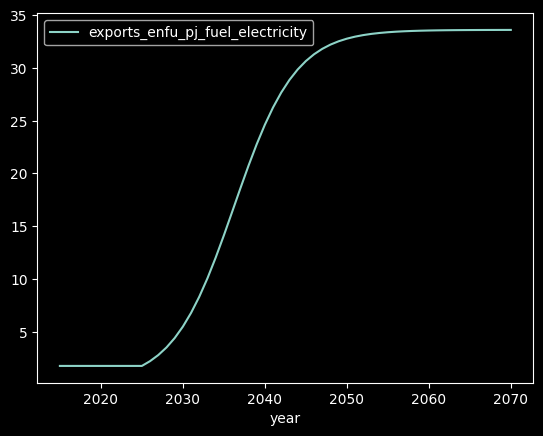

In [220]:
# get some fields
field_exp_elec = modvar_exports.build_fields(
    category_restrictions = models.model_enercons.cat_enfu_electricity
)
field_imp_elec = modvar_import_frac.build_fields(
    category_restrictions = models.model_enercons.cat_enfu_electricity
)
field_year = time_periods.field_year

# use data from Table 4 (see above||)
prod = 498.54
imp = 3.54
exp = 41.69
frac_imp = imp/(prod - exp)

exp_2023 = exp*ged_crude_pj_ktoe#*um_energy.convert("pj", "mwy")

# use increase from 170 to 2500 to represent export increase
y0 = 2025
y1 = 2040
t0 = time_periods.year_to_tp(y0, )
t1 = time_periods.year_to_tp(y1, )


vec_ramp = sf.ramp_vector(
    df_exports.shape[0],
    alpha_logistic = 1,
    r_0 = t0,
    #r_1 = t1,
    window_logistic = (-3, 9),
)


delta = exp_2023*(2500/170) - exp_2023
exp_max = delta/vec_ramp[t1]

delta_final = exp_max - exp_2023
vec_exps = exp_2023 + vec_ramp*delta_final

# export year range
ye0 = df_exports[field_year].min()
ye1 = df_exports[field_year].max()

# build a dataframe
df_exp_final = pd.DataFrame(
    {
        time_periods.field_year: range(ye0, ye1 + 1),
        field_exp_elec: vec_exps, 
    }
)
df_exp_final.plot(x = field_year, )


#### perform scaling


In [221]:
exp_memd_2023_reported_bkwh = um_energy.convert("pj", "kwh")*exp_2023/1000000000

field_year = time_periods.field_year
year = 2023
tp_2023 = time_periods.year_to_tp(year)
w = np.where(df_eia[field_year].to_numpy() == year)[0]

# get the scalar and apply
val_eia = df_eia[_FIELD_EIA_EXPORTS].iloc[w[0]]
scalar_eia = exp_memd_2023_reported_bkwh/val_eia
scalar_eia = um_energy.convert("kwh", "pj")*1e9

df_eia[_FIELD_EIA_EXPORTS] *= scalar_eia



##  BUILD COMBINED DF

df_exp_elec = pd.concat(
    [
        df_eia
        .rename(
            columns = {_FIELD_EIA_EXPORTS: field_exp_elec, }
        ),
        df_exp_final[
            ~df_exp_final[field_year].isin(df_eia[field_year].to_numpy())
        ]
        .reset_index(drop = True, )
    ]
)

# update exports
df_exports = sf.match_df_to_target_df(
    df_exports,
    df_exp_elec,
    [field_year],
    overwrite_only = False,
    try_interpolate = True,
)

# add constant import fraction
df_import_fractions[field_imp_elec] = frac_imp

## Finalize exports/imports

In [231]:
df_exports_out = _MODVAR_EXPORTS.get_from_dataframe(
    df_exports, 
    extraction_logic = "any_fill",
    fields_additional = [time_periods.field_year],
    fill_value = 0.0,
)

# finalize exports/imports
df_import_fractions_out = _MODVAR_IMPORTS.get_from_dataframe(
    df_import_fractions, 
    extraction_logic = "any_fill",
    fields_additional = [time_periods.field_year],
    fill_value = 1.0,
)

# Export

In [232]:
df_exports_out.to_csv(
    cdn._PATH_OUTPUTS.joinpath(f"{modvar_exports.name_fs_safe.upper()}.csv"),
    encoding = "UTF-8",
    index = None, 
)

df_import_fractions_out.to_csv(
    cdn._PATH_OUTPUTS.joinpath(f"{modvar_import_frac.name_fs_safe.upper()}.csv"),
    encoding = "UTF-8",
    index = None, 
)
